# Stack Exchange question-thread EDA

**Objective.** The analysis describes one Stack Exchange community and a selected question period, identifies human-response patterns, and prepares concrete questions for qualitative analysis.

**Table unit.** Each row represents one question. Answer, acceptance, comment, closure, score, view, and timing fields describe observable community activity.

**Analytical limit.** These indicators support investigation. Difficulty labels require a separate documented assessment.

## Data origin and table structure

- Stack Exchange public data dumps use XML files.
- `Posts.xml` stores questions and answers. `PostTypeId = 1` identifies a question and `PostTypeId = 2` identifies an answer.
- `Comments.xml` stores comments separately. The project counts comments attached directly to questions.
- `Votes.xml` records answer-acceptance events at calendar-day precision.
- `build_characteristics.py` combines these sources into one TSV table with one row per question.
- `config/characteristics.tsv` and `docs/reference/data-dictionary.xlsx` define the 49 fields, their sources, calculations, interpretations, and empty-value meanings.

The dump is a snapshot. Scores, views, answer counts, comments, and moderation events describe the state available at that snapshot.

## Upstream extraction and characteristic calculation

The EDA starts from `thread_characteristics.tsv`. The file is produced before notebook execution by `src/build_characteristics.py`.

| Build parameter | Meaning and effect |
|---|---|
| `--dump-dir` | Folder containing the compatible `Posts.xml`, `Comments.xml`, and `Votes.xml` source files. |
| `--site` | Community host stored as provenance and used to construct question and answer links, for example `superuser.com`. |
| `--dump-date` | Snapshot date associated with the downloaded dump. It defines the latest observable date for snapshot-based measurements. |
| `--start-date`, `--end-date` | Inclusive question-creation dates used during the build. Questions outside this source period are absent from the resulting TSV. |
| `--output-dir` | Destination folder for `thread_characteristics.tsv`, `validation.tsv`, and `run_metadata.json`. |
| `--schema` | Optional characteristic specification. The maintained default is `config/characteristics.tsv`. |
| `--limit` | Optional maximum number of chronologically selected questions. Its omission processes the complete source period. |
| `--overwrite` | Explicit permission to replace the three canonical files already present in the output folder. |

The two XML extraction routes have separate parameters:

| Extraction route | Main parameters | Result |
|---|---|---|
| `src/extract_threads.py` | Source-data folder, output XML path, and one or more question IDs | One XML file containing each selected question, its direct comments, and all available answers |
| `src/extract_request_summary.py` | Source-data folder, output XML path, question IDs, and an optional field-selection TSV | One XML file containing the selected fields in the configured order |

The notebook period settings select rows already present in the TSV. Questions excluded during the upstream build remain outside the EDA. Exact commands are documented in the project README under **Command-line interfaces** and **Notebook interface**.

In [1]:
# Libraries used directly for tables, statistics, and plots.
from itertools import combinations
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.ticker import MaxNLocator
from scipy import stats

## Editable settings

The next cell is the only routine editing point.

### Input and period

- **`DATA_FILE`** — TSV produced by `build_characteristics.py`. Example: `Path("../data/processed/example-run/thread_characteristics.tsv")`.
- **`PERIOD_MODE`** — question-period selection method: `"all"`, `"date_range"`, or `"year_range"`.
- **`START_DATE`, `END_DATE`** — inclusive `YYYY-MM-DD` limits used only with `PERIOD_MODE = "date_range"`. Example: `"2023-03-15"` through `"2023-08-31"`.
- **`START_YEAR`, `END_YEAR`** — inclusive whole-year limits used only with `PERIOD_MODE = "year_range"`. Example: `2022` through `2024`.

Examples:

```python
# Every question in the TSV
PERIOD_MODE = "all"
START_DATE = END_DATE = None
START_YEAR = END_YEAR = None

# Explicit calendar dates
PERIOD_MODE = "date_range"
START_DATE, END_DATE = "2023-01-01", "2023-06-30"
START_YEAR = END_YEAR = None

# Complete calendar years
PERIOD_MODE = "year_range"
START_YEAR, END_YEAR = 2022, 2024
START_DATE = END_DATE = None
```

### Outlier result

- **`OUTLIER_OUTPUT_FILE`** — optional TSV destination for all questions with at least one Tukey high-outlier flag. `None` keeps the separate dataset in the notebook as `outlier_questions`. Example: `Path("../data/processed/example-run/outlier_questions.tsv")` writes it to disk.

### Display and evidence rules

- **`MIN_TAG_QUESTIONS`** — minimum questions required for a tag percentage comparison.
- **`TOP_TAGS_TO_SHOW`** — maximum number of frequent tags shown.
- **`MIN_CORRELATION_OBSERVATIONS`** — minimum complete rows required for one correlation.
- **`MIN_ABSOLUTE_RHO`** — minimum displayed absolute Spearman correlation.
- **`FDR_ALPHA`** — false-discovery-rate limit for the correlation search.
- **`MAX_CASES_TO_SHOW`** — maximum questions in the final inspection table.

In [2]:
# Characteristic table analyzed by this run.
DATA_FILE = Path("../data/examples/characteristics_pilot.tsv")

# Question-period selection: "all", "date_range", or "year_range".
PERIOD_MODE = "all"
START_DATE = None
END_DATE = None
START_YEAR = None
END_YEAR = None

# Optional TSV export for the separate high-outlier dataset.
OUTLIER_OUTPUT_FILE = None

# Evidence-selection settings for tags, correlations, and inspection cases.
MIN_TAG_QUESTIONS = 20
TOP_TAGS_TO_SHOW = 15
MIN_CORRELATION_OBSERVATIONS = 20
MIN_ABSOLUTE_RHO = 0.30
FDR_ALPHA = 0.05
MAX_CASES_TO_SHOW = 8

## 1. Table loading and verification

This section checks the editable settings, required fields, data types, date logic, and internal consistency before any figure is produced. Execution stops with a specific error when the input does not satisfy the documented contract.

In [3]:
# Input-path and period-setting validation.
if not isinstance(DATA_FILE, (str, Path)):
    raise TypeError("DATA_FILE must be a file path")
DATA_FILE = Path(DATA_FILE)

allowed_period_modes = {"all", "date_range", "year_range"}
if PERIOD_MODE not in allowed_period_modes:
    raise ValueError("PERIOD_MODE must be 'all', 'date_range', or 'year_range'")

if PERIOD_MODE == "all":
    if any(value is not None for value in [START_DATE, END_DATE, START_YEAR, END_YEAR]):
        raise ValueError("All date and year limits must be None when PERIOD_MODE is 'all'")
elif PERIOD_MODE == "date_range":
    if not isinstance(START_DATE, str) or not isinstance(END_DATE, str):
        raise TypeError("START_DATE and END_DATE must use the YYYY-MM-DD text format")
    period_start = pd.to_datetime(START_DATE, format="%Y-%m-%d", errors="raise")
    period_end = pd.to_datetime(END_DATE, format="%Y-%m-%d", errors="raise")
    if period_start > period_end:
        raise ValueError("START_DATE must be on or before END_DATE")
    if START_YEAR is not None or END_YEAR is not None:
        raise ValueError("START_YEAR and END_YEAR must be None in date_range mode")
else:
    if any(isinstance(value, bool) or not isinstance(value, int) for value in [START_YEAR, END_YEAR]):
        raise TypeError("START_YEAR and END_YEAR must be whole calendar years")
    if START_YEAR > END_YEAR:
        raise ValueError("START_YEAR must be less than or equal to END_YEAR")
    if START_DATE is not None or END_DATE is not None:
        raise ValueError("START_DATE and END_DATE must be None in year_range mode")

In [4]:
# Output-path and evidence-setting validation.
if OUTLIER_OUTPUT_FILE is not None:
    if not isinstance(OUTLIER_OUTPUT_FILE, (str, Path)):
        raise TypeError("OUTLIER_OUTPUT_FILE must be a file path or None")
    OUTLIER_OUTPUT_FILE = Path(OUTLIER_OUTPUT_FILE)
    if OUTLIER_OUTPUT_FILE.resolve() == DATA_FILE.resolve():
        raise ValueError("OUTLIER_OUTPUT_FILE must differ from DATA_FILE")

positive_integer_settings = {
    "MIN_TAG_QUESTIONS": MIN_TAG_QUESTIONS,
    "TOP_TAGS_TO_SHOW": TOP_TAGS_TO_SHOW,
    "MIN_CORRELATION_OBSERVATIONS": MIN_CORRELATION_OBSERVATIONS,
    "MAX_CASES_TO_SHOW": MAX_CASES_TO_SHOW,
}
for name, value in positive_integer_settings.items():
    if isinstance(value, bool) or not isinstance(value, int) or value < 1:
        raise ValueError(f"{name} must be a whole number greater than zero")

if MIN_CORRELATION_OBSERVATIONS < 3:
    raise ValueError("MIN_CORRELATION_OBSERVATIONS must be at least 3")
for name, value in {"MIN_ABSOLUTE_RHO": MIN_ABSOLUTE_RHO, "FDR_ALPHA": FDR_ALPHA}.items():
    if isinstance(value, bool) or not isinstance(value, (int, float)):
        raise TypeError(f"{name} must be a number")
if not 0 <= MIN_ABSOLUTE_RHO <= 1:
    raise ValueError("MIN_ABSOLUTE_RHO must be between 0 and 1")
if not 0 < FDR_ALPHA <= 1:
    raise ValueError("FDR_ALPHA must be greater than 0 and at most 1")

display(Markdown("**Settings check:** all editable settings are valid."))

**Settings check:** all editable settings are valid.

In [5]:
# File loading and required-column check.
if not DATA_FILE.is_file():
    raise FileNotFoundError(f"Characteristic table not found: {DATA_FILE.resolve()}")

data = pd.read_csv(DATA_FILE, sep="\t", low_memory=False)
source_row_count = len(data)
source_columns = data.columns.tolist()
source_column_count = len(source_columns)
if data.empty:
    raise ValueError("The characteristic table contains no question rows")

required_columns = {
    "site", "dump_snapshot_date", "question_id", "question_url",
    "question_creation_datetime", "question_title", "question_tags",
    "question_score", "question_view_count", "question_word_count",
    "code_character_count", "link_count", "image_count", "tag_count",
    "stackexchange_answer_count", "has_stackexchange_answer",
    "stackexchange_comment_count", "available_answer_count",
    "has_available_answer", "first_answer_creation_datetime",
    "time_to_first_answer_hours", "median_answer_response_hours",
    "accepted_answer_id", "accepted_answer_available",
    "accepted_answer_creation_datetime",
    "time_to_eventually_accepted_answer_post_hours", "acceptance_date",
    "days_to_acceptance", "closed_datetime", "answer_score_spread",
    "available_question_comment_count", "comments_before_first_answer",
    "observation_days_at_dump",
}
missing_columns = sorted(required_columns - set(data.columns))
if missing_columns:
    raise ValueError("Missing required column(s): " + ", ".join(missing_columns))

In [6]:
# Source-date, numeric, and TRUE/FALSE conversion.
date_columns = [
    "dump_snapshot_date", "question_creation_datetime",
    "first_answer_creation_datetime", "accepted_answer_creation_datetime",
    "acceptance_date", "closed_datetime",
]
for column in date_columns:
    data[column] = pd.to_datetime(data[column], errors="raise")

numeric_columns = [
    "question_score", "question_view_count", "question_word_count",
    "code_character_count", "link_count", "image_count", "tag_count",
    "stackexchange_answer_count", "stackexchange_comment_count",
    "available_answer_count", "time_to_first_answer_hours",
    "median_answer_response_hours", "time_to_eventually_accepted_answer_post_hours",
    "days_to_acceptance", "answer_score_spread",
    "available_question_comment_count", "comments_before_first_answer",
    "observation_days_at_dump",
]
for column in numeric_columns:
    data[column] = pd.to_numeric(data[column], errors="raise")

boolean_columns = [
    "has_stackexchange_answer", "has_available_answer", "accepted_answer_available"
]
for column in boolean_columns:
    boolean_text = data[column].astype("string").str.upper()
    invalid = boolean_text.notna() & ~boolean_text.isin(["TRUE", "FALSE"])
    if invalid.any():
        raise ValueError(f"{column} contains a value outside TRUE, FALSE, and empty")
    if column != "has_stackexchange_answer" and boolean_text.isna().any():
        raise ValueError(f"{column} contains an empty value")
    data[column] = boolean_text.map({"TRUE": True, "FALSE": False}).astype("boolean")

In [7]:
# Cross-field and dataset-level consistency checks.
expected_stackexchange_flag = data["stackexchange_answer_count"].gt(0).astype("boolean")
expected_stackexchange_flag[data["stackexchange_answer_count"].isna()] = pd.NA
if not data["has_stackexchange_answer"].equals(expected_stackexchange_flag):
    raise ValueError("has_stackexchange_answer disagrees with stackexchange_answer_count")
expected_available_flag = data["available_answer_count"].gt(0).astype("boolean")
if not data["has_available_answer"].equals(expected_available_flag):
    raise ValueError("has_available_answer disagrees with available_answer_count")
if data["question_id"].isna().any() or data["question_id"].duplicated().any():
    raise ValueError("Question identifiers must be present and unique")

nonnegative_columns = [
    "question_view_count", "question_word_count", "code_character_count",
    "link_count", "image_count", "tag_count", "available_answer_count",
    "time_to_first_answer_hours", "median_answer_response_hours",
    "time_to_eventually_accepted_answer_post_hours", "days_to_acceptance",
    "answer_score_spread", "available_question_comment_count",
    "comments_before_first_answer", "observation_days_at_dump",
]
for column in nonnegative_columns:
    if (data[column].dropna() < 0).any():
        raise ValueError(f"{column} contains a negative value")

sites = data["site"].dropna().unique()
if len(sites) != 1:
    raise ValueError(f"Expected one site, found {len(sites)}")
snapshot_dates = data["dump_snapshot_date"].dropna().dt.normalize().unique()
if len(snapshot_dates) != 1:
    raise ValueError(f"Expected one dump snapshot date, found {len(snapshot_dates)}")
snapshot_date = data["dump_snapshot_date"].max().normalize()

In [8]:
# Chronological consistency checks for recorded events.
event_columns = [
    "first_answer_creation_datetime", "accepted_answer_creation_datetime", "closed_datetime"
]
for column in event_columns:
    available = data[column].notna()
    if (data.loc[available, column] < data.loc[available, "question_creation_datetime"]).any():
        raise ValueError(f"{column} contains a date before its question")
    if (data[column].dropna() > snapshot_date).any():
        raise ValueError(f"{column} contains a date after the dump snapshot")

available_acceptance = data["acceptance_date"].notna()
question_days = data["question_creation_datetime"].dt.normalize()
if (data.loc[available_acceptance, "acceptance_date"] < question_days[available_acceptance]).any():
    raise ValueError("acceptance_date contains a day before its question")
if (data["acceptance_date"].dropna() > snapshot_date).any():
    raise ValueError("acceptance_date contains a day after the dump snapshot")
if (data["question_creation_datetime"] > snapshot_date + pd.Timedelta(days=1)).any():
    raise ValueError("question_creation_datetime contains a date after the dump snapshot")

In [9]:
# Inclusive question-period selection.
question_days = data["question_creation_datetime"].dt.normalize()
if PERIOD_MODE == "all":
    selected = pd.Series(True, index=data.index)
    requested_period = "All question rows in the TSV"
    analysis_end_date = snapshot_date
elif PERIOD_MODE == "date_range":
    selected = question_days.between(period_start, period_end, inclusive="both")
    requested_period = f"{period_start:%Y-%m-%d} through {period_end:%Y-%m-%d}"
    analysis_end_date = min(period_end, snapshot_date)
else:
    selected = data["question_creation_datetime"].dt.year.between(START_YEAR, END_YEAR)
    requested_period = f"calendar years {START_YEAR} through {END_YEAR}"
    analysis_end_date = min(pd.Timestamp(END_YEAR, 12, 31), snapshot_date)

data = data.loc[selected].copy().reset_index(drop=True)
if data.empty:
    raise ValueError(f"No question rows match the selected period: {requested_period}")

data["has_accepted_answer"] = data["accepted_answer_id"].notna()
data["is_closed"] = data["closed_datetime"].notna()
selected_start = data["question_creation_datetime"].min().normalize()
selected_end = data["question_creation_datetime"].max().normalize()

In [10]:
# Compact description of the verified and filtered table.
summary = pd.DataFrame({
    "Item": [
        "Site", "Rows in source TSV", "Questions selected", "Source columns",
        "Requested period", "Selected question dates", "Outcome observation end",
        "Dump snapshot",
    ],
    "Value": [
        sites[0], f"{source_row_count:,}", f"{len(data):,}", f"{source_column_count:,}",
        requested_period, f"{selected_start:%Y-%m-%d} to {selected_end:%Y-%m-%d}",
        f"{analysis_end_date:%Y-%m-%d}", f"{snapshot_date:%Y-%m-%d}",
    ],
})
display(summary)

# Each later figure records whether sufficient evidence was available.
figure_status = []

,Item,Value
0,Site,softwareengineering.stackexchange.com
1,Rows in source TSV,20
2,Questions selected,20
3,Source columns,49
4,Requested period,All question rows in the TSV
5,Selected question dates,2024-01-01 to 2024-01-08
6,Outcome observation end,2026-04-20
7,Dump snapshot,2026-04-20


## 2. Figure 1 — Table quality and overall outcomes

Figure 1a counts selected questions reaching observable outcomes by the dump snapshot. The groups overlap: an accepted question is also answered, and a closed question can also be answered.

Figure 1b reports the largest empty-value shares among analysis measurements. Event-based fields remain empty when the corresponding event is absent. The consistency table compares related source and reconstructed values.

In [11]:
# Outcome counts and empty-value shares.
status_counts = pd.Series({
    "All selected questions": len(data),
    "Questions with an answer": int(data["has_available_answer"].sum()),
    "Questions with an accepted answer": int(data["has_accepted_answer"].sum()),
    "Closed questions": int(data["is_closed"].sum()),
})

availability_columns = [
    "time_to_first_answer_hours", "median_answer_response_hours",
    "time_to_eventually_accepted_answer_post_hours", "days_to_acceptance",
    "answer_score_spread", "question_view_count", "question_word_count",
    "code_character_count", "available_question_comment_count",
]
availability_labels = {
    "time_to_first_answer_hours": "Hours to first answer",
    "median_answer_response_hours": "Median answer delay",
    "time_to_eventually_accepted_answer_post_hours": "Hours to accepted-answer post",
    "days_to_acceptance": "Days to acceptance action",
    "answer_score_spread": "Answer-score spread",
    "question_view_count": "Question views",
    "question_word_count": "Question prose words",
    "code_character_count": "Code characters",
    "available_question_comment_count": "Question comments",
}
missing_percentages = (data[availability_columns].isna().mean() * 100).sort_values(ascending=False).head(7)
missing_percentages.index = [availability_labels[column] for column in missing_percentages.index]

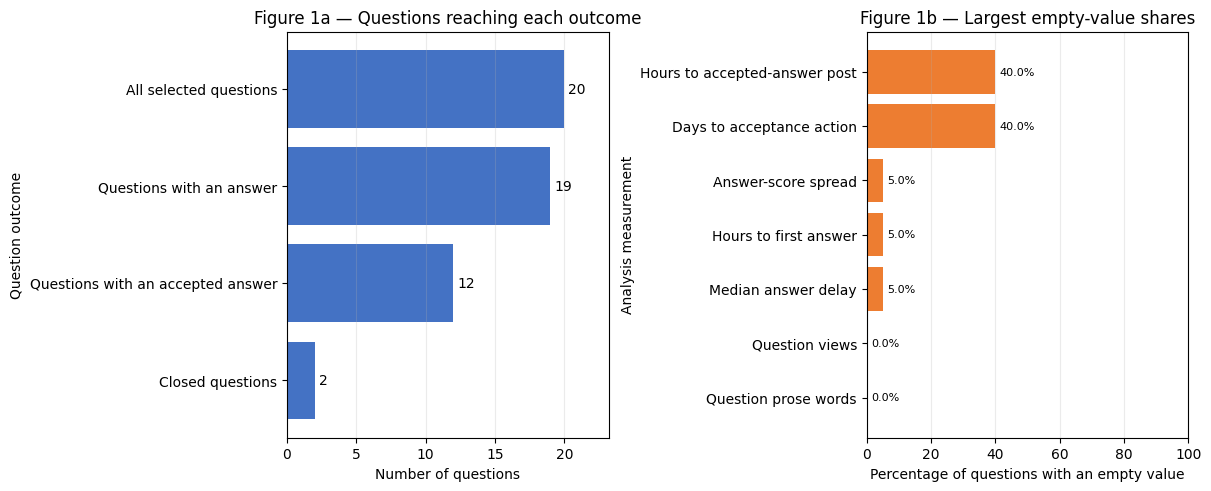

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), layout="constrained")
bars = axes[0].barh(status_counts.index, status_counts.values, color="#4472C4")
axes[0].invert_yaxis()
axes[0].set_title("Figure 1a — Questions reaching each outcome")
axes[0].set_xlabel("Number of questions")
axes[0].set_ylabel("Question outcome")
axes[0].grid(axis="x", alpha=0.25)
axes[0].bar_label(bars, labels=[f"{value:,}" for value in status_counts.values], padding=3)
axes[0].set_xlim(0, max(1, status_counts.max() * 1.16))

missing_to_plot = missing_percentages.sort_values()
bars = axes[1].barh(missing_to_plot.index, missing_to_plot.values, color="#ED7D31")
axes[1].set_title("Figure 1b — Largest empty-value shares")
axes[1].set_xlabel("Percentage of questions with an empty value")
axes[1].set_ylabel("Analysis measurement")
axes[1].set_xlim(0, 100)
axes[1].grid(axis="x", alpha=0.25)
axes[1].bar_label(bars, labels=[f"{value:.1f}%" for value in missing_to_plot.values], padding=3, fontsize=8)
plt.show()

In [13]:
# Source-count consistency and Figure 1 interpretation.
answer_count_difference = (
    data["stackexchange_answer_count"].notna()
    & data["stackexchange_answer_count"].ne(data["available_answer_count"])
)
comment_count_difference = (
    data["stackexchange_comment_count"].notna()
    & data["stackexchange_comment_count"].ne(data["available_question_comment_count"])
)
accepted_row_missing = data["has_accepted_answer"] & ~data["accepted_answer_available"].fillna(False)
acceptance_date_missing = data["has_accepted_answer"] & data["acceptance_date"].isna()
consistency = pd.DataFrame({
    "Consistency check": [
        "Stack Exchange answer count differs from available answer rows",
        "Stack Exchange comment count differs from available question-comment rows",
        "Accepted-answer identifier has no available answer row",
        "Accepted-answer identifier has no recorded acceptance date",
    ],
    "Questions": [
        int(answer_count_difference.sum()), int(comment_count_difference.sum()),
        int(accepted_row_missing.sum()), int(acceptance_date_missing.sum()),
    ],
})
display(consistency)

total = len(data)
display(Markdown(
    "**Figure 1 interpretation**  \n"
    f"- **Answered:** {status_counts['Questions with an answer']:,} questions ({status_counts['Questions with an answer'] / total:.1%}).  \n"
    f"- **Accepted:** {status_counts['Questions with an accepted answer']:,} questions ({status_counts['Questions with an accepted answer'] / total:.1%}).  \n"
    f"- **Closed:** {status_counts['Closed questions']:,} questions ({status_counts['Closed questions'] / total:.1%}).  \n"
    f"- The largest empty-value share is **{missing_percentages.iloc[0]:.1f}%** for **{missing_percentages.index[0]}**.  \n"
    "- Count differences remain visible as source-state evidence."
))
figure_status.append({"Figure": "1", "Status": "Produced", "Evidence": "Outcome, availability, and consistency checks"})

,Consistency check,Questions
0,Stack Exchange answer count differs from avail...,0
1,Stack Exchange comment count differs from avai...,0
2,Accepted-answer identifier has no available an...,0
3,Accepted-answer identifier has no recorded acc...,0


**Figure 1 interpretation**  
- **Answered:** 19 questions (95.0%).  
- **Accepted:** 12 questions (60.0%).  
- **Closed:** 2 questions (10.0%).  
- The largest empty-value share is **40.0%** for **Hours to accepted-answer post**.  
- Count differences remain visible as source-state evidence.

## 3. Figure 2 — Questions and outcomes by posting month and year

Each period groups questions by their creation date. The outcome counts describe whether those questions had an available answer, an accepted answer, or a closure by the dump snapshot. Answered and unanswered counts divide the total; accepted and closed counts overlap with those groups.

Monthly lines preserve a readable date axis across short and long ranges. Annual bars provide exact broader comparisons without combining unequal calendar periods.

In [14]:
# Monthly and annual posting-cohort counts.
period_rows = data.assign(
    creation_month=data["question_creation_datetime"].dt.to_period("M"),
    creation_year=data["question_creation_datetime"].dt.year,
)

monthly_outcomes = period_rows.groupby("creation_month").agg(
    questions=("question_id", "size"),
    answered_questions=("has_available_answer", "sum"),
    accepted_questions=("has_accepted_answer", "sum"),
    closed_questions=("is_closed", "sum"),
)
yearly_outcomes = period_rows.groupby("creation_year").agg(
    questions=("question_id", "size"),
    answered_questions=("has_available_answer", "sum"),
    accepted_questions=("has_accepted_answer", "sum"),
    closed_questions=("is_closed", "sum"),
)
for table in [monthly_outcomes, yearly_outcomes]:
    table["unanswered_questions"] = table["questions"] - table["answered_questions"]

outcome_columns = [
    "questions", "answered_questions", "unanswered_questions",
    "accepted_questions", "closed_questions",
]
outcome_labels = [
    "All questions", "With an answer", "Without an answer",
    "With an accepted answer", "Closed",
]
outcome_colors = ["#7F7F7F", "#70AD47", "#F4B183", "#4472C4", "#A64D79"]

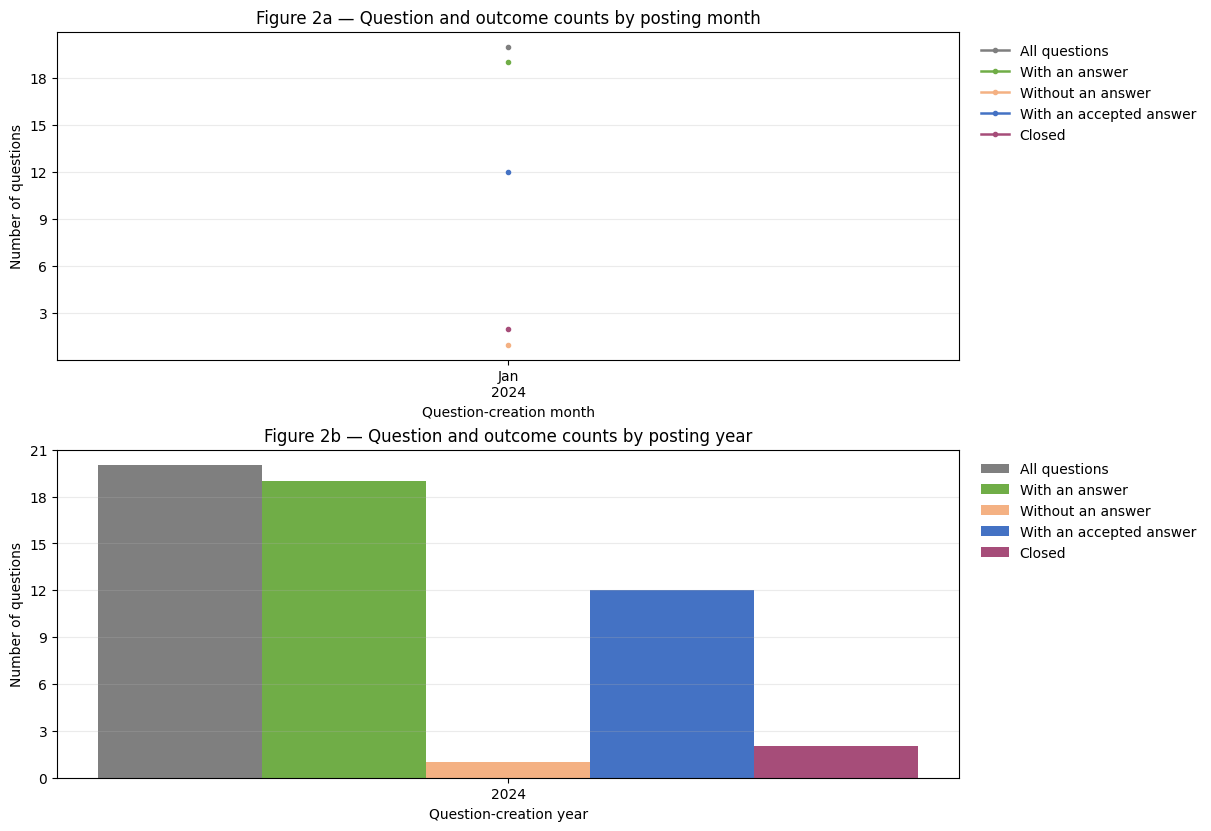

In [15]:
# Figure 2a: monthly counts; Figure 2b: annual counts.
fig, axes = plt.subplots(2, 1, figsize=(12, 8.2), layout="constrained")
month_dates = monthly_outcomes.index.to_timestamp()
for column, label, color in zip(outcome_columns, outcome_labels, outcome_colors):
    axes[0].plot(month_dates, monthly_outcomes[column], marker="o", markersize=3, linewidth=1.8, label=label, color=color)
axes[0].set_title("Figure 2a — Question and outcome counts by posting month")
axes[0].set_xlabel("Question-creation month")
axes[0].set_ylabel("Number of questions")
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))
month_locator = mdates.AutoDateLocator(minticks=3, maxticks=10)
if len(month_dates) == 1:
    axes[0].set_xticks(month_dates, [month_dates[0].strftime("%b\n%Y")])
    axes[0].set_xlim(month_dates[0] - pd.Timedelta(days=15), month_dates[0] + pd.Timedelta(days=15))
else:
    axes[0].xaxis.set_major_locator(month_locator)
    axes[0].xaxis.set_major_formatter(mdates.ConciseDateFormatter(month_locator))
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend(frameon=False, ncols=1, loc="upper left", bbox_to_anchor=(1.01, 1))

year_positions = np.arange(len(yearly_outcomes))
bar_width = 0.16
for offset, (column, label, color) in enumerate(zip(outcome_columns, outcome_labels, outcome_colors)):
    axes[1].bar(year_positions + (offset - 2) * bar_width, yearly_outcomes[column], width=bar_width, label=label, color=color)
axes[1].set_xticks(year_positions, yearly_outcomes.index.astype(str))
axes[1].set_title("Figure 2b — Question and outcome counts by posting year")
axes[1].set_xlabel("Question-creation year")
axes[1].set_ylabel("Number of questions")
axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(frameon=False, ncols=1, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.show()

In [16]:
# Exact counts supporting Figure 2.
monthly_table = monthly_outcomes.reset_index()
monthly_table["creation_month"] = monthly_table["creation_month"].astype(str)
monthly_table = monthly_table.rename(columns={
    "creation_month": "Question-creation month",
    "questions": "Questions",
    "answered_questions": "With answer",
    "unanswered_questions": "Without answer",
    "accepted_questions": "With accepted answer",
    "closed_questions": "Closed",
})
if len(monthly_table) <= 24:
    display(monthly_table)
else:
    display(pd.concat([monthly_table.head(12), monthly_table.tail(12)]))
    display(Markdown(f"Monthly table display: first and last 12 of **{len(monthly_table)}** months."))

yearly_table = yearly_outcomes.reset_index().rename(columns={
    "creation_year": "Question-creation year",
    "questions": "Questions", "answered_questions": "With answer",
    "unanswered_questions": "Without answer",
    "accepted_questions": "With accepted answer", "closed_questions": "Closed",
})
display(yearly_table)

largest_month = monthly_outcomes["questions"].idxmax()
largest_year = yearly_outcomes["questions"].idxmax()
display(Markdown(
    "**Figure 2 interpretation**  \n"
    f"- **{largest_month.strftime('%B %Y')}** has the largest monthly posting cohort: **{int(monthly_outcomes.loc[largest_month, 'questions']):,} questions**.  \n"
    f"- **{largest_year}** has the largest annual posting cohort: **{int(yearly_outcomes.loc[largest_year, 'questions']):,} questions**.  \n"
    "- Outcome bars remain subsets of the questions posted in the corresponding period."
))
figure_status.append({"Figure": "2", "Status": "Produced", "Evidence": f"{len(monthly_outcomes)} months and {len(yearly_outcomes)} years"})

,Question-creation month,Questions,With answer,With accepted answer,Closed,Without answer
0,2024-01,20,19,12,2,1


,Question-creation year,Questions,With answer,With accepted answer,Closed,Without answer
0,2024,20,19,12,2,1


**Figure 2 interpretation**  
- **January 2024** has the largest monthly posting cohort: **20 questions**.  
- **2024** has the largest annual posting cohort: **20 questions**.  
- Outcome bars remain subsets of the questions posted in the corresponding period.

## 4. Figure 3 — Cumulative monthly outcome evolution

Every month includes selected questions and events from that month and all preceding months. The stacked areas divide all selected questions posted so far into questions that had received a first answer by that month and questions still waiting. The lines add recorded acceptance and closure events.

The timeline ends at the selected outcome-observation end. Events recorded later remain outside this period view.

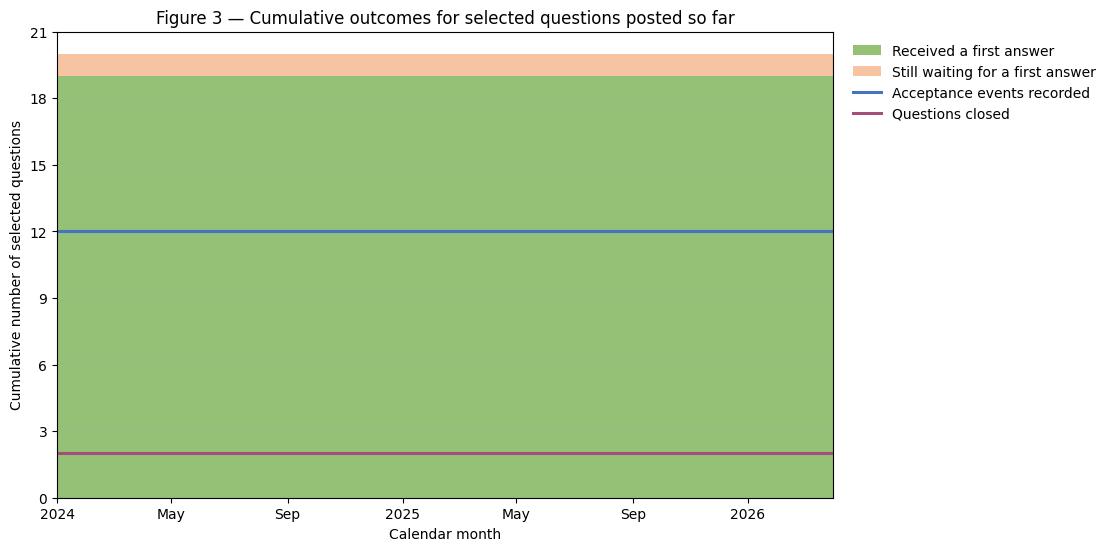

**Figure 3 interpretation**  
- The cumulative timeline covers **January 2024** through **April 2026**.  
- By its end, **19** questions had received a first answer and **1** were still waiting.  
- **12** acceptance events and **2** closures were recorded in the timeline.  
- A flat segment means that no additional selected question reached that event during the segment.

In [17]:
first_month = data["question_creation_datetime"].min().to_period("M").to_timestamp()
last_month = analysis_end_date.to_period("M").to_timestamp()
months = pd.date_range(first_month, last_month, freq="MS")

def cumulative_monthly_count(dates):
    """Returns cumulative event counts on the shared monthly timeline."""
    event_months = dates.dropna().dt.to_period("M").dt.to_timestamp()
    return event_months.value_counts().reindex(months, fill_value=0).cumsum()

posted = cumulative_monthly_count(data["question_creation_datetime"])
answered = cumulative_monthly_count(data["first_answer_creation_datetime"])
acceptance_events = cumulative_monthly_count(data["acceptance_date"])
closed = cumulative_monthly_count(data["closed_datetime"])
still_waiting = posted - answered

fig, ax = plt.subplots(figsize=(11, 5.4), layout="constrained")
ax.stackplot(
    months, answered, still_waiting,
    labels=["Received a first answer", "Still waiting for a first answer"],
    colors=["#70AD47", "#F4B183"], alpha=0.75,
)
ax.plot(months, acceptance_events, color="#4472C4", linewidth=2.2, label="Acceptance events recorded")
ax.plot(months, closed, color="#A64D79", linewidth=2.2, label="Questions closed")
ax.set_title("Figure 3 — Cumulative outcomes for selected questions posted so far")
ax.set_xlabel("Calendar month")
ax.set_ylabel("Cumulative number of selected questions")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
locator = mdates.AutoDateLocator(minticks=4, maxticks=9)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
if len(months) == 1:
    ax.set_xlim(months[0] - pd.Timedelta(days=15), months[0] + pd.Timedelta(days=15))
else:
    ax.set_xlim(months[0], months[-1])
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.show()

display(Markdown(
    "**Figure 3 interpretation**  \n"
    f"- The cumulative timeline covers **{first_month:%B %Y}** through **{last_month:%B %Y}**.  \n"
    f"- By its end, **{int(answered.iloc[-1]):,}** questions had received a first answer and **{int(still_waiting.iloc[-1]):,}** were still waiting.  \n"
    f"- **{int(acceptance_events.iloc[-1]):,}** acceptance events and **{int(closed.iloc[-1]):,}** closures were recorded in the timeline.  \n"
    "- A flat segment means that no additional selected question reached that event during the segment."
))
figure_status.append({"Figure": "3", "Status": "Produced", "Evidence": f"{len(months)} cumulative calendar months"})

## 5. Figure 4 — First-response evolution for every posting-month cohort

A posting-month cohort contains questions created in the same calendar month. Each subplot follows one cohort from its posting month through the selected outcome-observation end.

The 49-field table records each question's first-answer timestamp and its total answer count at the dump snapshot. Consequently, the supported temporal measure is **first-response acquisition**: the cumulative number of cohort questions that had received their first available answer by each later month.

The dashed line marks the complete cohort size. The distance between the cumulative response line and that reference is the number still awaiting a first answer at the corresponding month end.

In [18]:
# Monthly first-response evolution for each posting cohort.
creation_period = data["question_creation_datetime"].dt.to_period("M")
first_answer_period = data["first_answer_creation_datetime"].dt.to_period("M")
observation_end_period = analysis_end_date.to_period("M")
evolution_rows = []
cohort_summary_rows = []

for cohort_month in sorted(creation_period.unique()):
    cohort_mask = creation_period.eq(cohort_month)
    cohort_size = int(cohort_mask.sum())
    cohort_answers = first_answer_period[cohort_mask].dropna()
    timeline = pd.period_range(cohort_month, observation_end_period, freq="M")
    for observation_month in timeline:
        evolution_rows.append({
            "cohort_month": cohort_month,
            "observation_month": observation_month,
            "answered_by_month": int(cohort_answers.le(observation_month).sum()),
            "cohort_size": cohort_size,
        })
    same_month = int(cohort_answers.eq(cohort_month).sum())
    answered_by_end = int(cohort_answers.le(observation_end_period).sum())
    cohort_summary_rows.append({
        "Posting month": str(cohort_month), "Questions": cohort_size,
        "First answer in posting month": same_month,
        "First answer by observation end": answered_by_end,
        "Answered by observation end (%)": 100 * answered_by_end / cohort_size,
    })

response_evolution = pd.DataFrame(evolution_rows)
response_cohort_summary = pd.DataFrame(cohort_summary_rows)

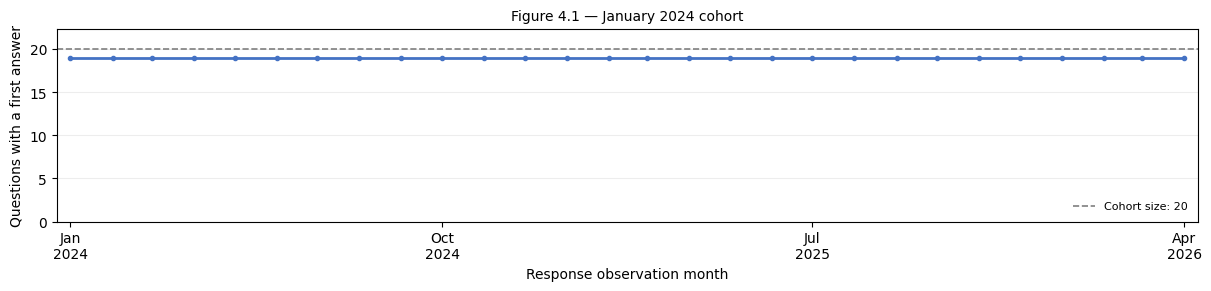

In [19]:
# Figure 4: one subfigure per question-posting month, grouped into annual pages.
subfigure_number = 1
for cohort_year in sorted({period.year for period in creation_period.unique()}):
    year_cohorts = sorted(period for period in creation_period.unique() if period.year == cohort_year)
    columns = min(3, len(year_cohorts))
    rows = int(np.ceil(len(year_cohorts) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(12, 2.8 * rows), squeeze=False, layout="constrained")
    for ax, cohort_month in zip(axes.flat, year_cohorts):
        evolution = response_evolution[response_evolution["cohort_month"].eq(cohort_month)]
        x_values = evolution["observation_month"].dt.to_timestamp()
        ax.step(x_values, evolution["answered_by_month"], where="post", color="#4472C4", linewidth=2)
        ax.plot(x_values, evolution["answered_by_month"], "o", color="#4472C4", markersize=3)
        cohort_size = int(evolution["cohort_size"].iloc[0])
        ax.axhline(cohort_size, color="#7F7F7F", linestyle="--", linewidth=1.2, label=f"Cohort size: {cohort_size:,}")
        ax.set_title(f"Figure 4.{subfigure_number} — {cohort_month.strftime('%B %Y')} cohort", fontsize=10)
        ax.set_xlabel("Response observation month")
        ax.set_ylabel("Questions with a first answer")
        ax.set_ylim(0, max(1, cohort_size * 1.12))
        ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
        tick_count = min(4, len(x_values))
        tick_indices = np.unique(np.linspace(0, len(x_values) - 1, tick_count, dtype=int))
        tick_dates = x_values.iloc[tick_indices]
        ax.set_xticks(tick_dates, [date.strftime("%b\n%Y") for date in tick_dates])
        if len(x_values) == 1:
            ax.set_xlim(x_values.iloc[0] - pd.Timedelta(days=15), x_values.iloc[0] + pd.Timedelta(days=15))
        else:
            ax.set_xlim(x_values.iloc[0] - pd.Timedelta(days=10), x_values.iloc[-1] + pd.Timedelta(days=10))
        ax.grid(axis="y", alpha=0.22)
        ax.legend(frameon=False, fontsize=8, loc="lower right")
        subfigure_number += 1
    for ax in axes.flat[len(year_cohorts):]:
        ax.set_axis_off()
    plt.show()

In [20]:
# Exact cohort results and Figure 4 interpretation.
if len(response_cohort_summary) <= 24:
    display(response_cohort_summary.round(1))
else:
    display(pd.concat([response_cohort_summary.head(12), response_cohort_summary.tail(12)]).round(1))
    display(Markdown(f"Cohort table display: first and last 12 of **{len(response_cohort_summary)}** cohorts."))

highest_response_row = response_cohort_summary.loc[
    response_cohort_summary["Answered by observation end (%)"].idxmax()
]
display(Markdown(
    "**Figure 4 interpretation**  \n"
    f"- The figure contains **{len(response_cohort_summary):,}** posting-month subfigures.  \n"
    f"- **{highest_response_row['Posting month']}** has the highest first-response coverage by the observation end: "
    f"**{int(highest_response_row['First answer by observation end']):,} of {int(highest_response_row['Questions']):,} questions "
    f"({highest_response_row['Answered by observation end (%)']:.1f}%)**.  \n"
    "- Later cohorts have shorter follow-up intervals, so comparisons with earlier cohorts require the displayed timeline."
))
figure_status.append({"Figure": "4", "Status": "Produced", "Evidence": f"{len(response_cohort_summary)} posting-month cohorts"})

,Posting month,Questions,First answer in posting month,First answer by observation end,Answered by observation end (%)
0,2024-01,20,19,19,95.0


**Figure 4 interpretation**  
- The figure contains **1** posting-month subfigures.  
- **2024-01** has the highest first-response coverage by the observation end: **19 of 20 questions (95.0%)**.  
- Later cohorts have shorter follow-up intervals, so comparisons with earlier cohorts require the displayed timeline.

## 6. Figures 5 and 6 — Numeric distributions

The histograms use linear axes and equal-width bins. Axis labels state the measured value and unit. Compact integer ranges use one bar for each actual whole-number result.

The displayed range contains the central 95% of most measurements and the central 80% of response and acceptance delays. Values beyond the displayed range remain counted in the interpretation with their observed minimum and maximum. This preserves a readable common range while accounting for every available value.

In [21]:
def draw_distribution(ax, series, title, x_label, whole_numbers=False, lower_quantile=0, upper_quantile=0.95):
    """Draws one readable linear distribution and returns its summary."""
    values = series.dropna().astype(float)
    if values.empty:
        ax.text(0.5, 0.5, "No available values", ha="center", va="center")
        ax.set_axis_off()
        return None

    lower = float(values.quantile(lower_quantile)) if lower_quantile else float(values.min())
    upper = float(values.quantile(upper_quantile))
    if values.min() >= 0:
        lower = 0.0
    if whole_numbers:
        lower, upper = float(np.floor(lower)), float(np.ceil(upper))
    if upper <= lower:
        upper = max(float(values.max()), lower + 1)

    shown = values[(values >= lower) & (values <= upper)]
    if whole_numbers and upper - lower <= 20:
        points = np.arange(int(lower), int(upper) + 1)
        counts = shown.round().astype(int).value_counts().reindex(points, fill_value=0)
        ax.bar(points, counts.values, width=0.8, color="#5B9BD5")
        tick_step = max(1, int(np.ceil(len(points) / 7)))
        ax.set_xticks(points[::tick_step])
        ax.set_xlim(lower - 0.45, upper + 0.45)
    else:
        bin_count = min(30, max(8, int(np.sqrt(len(shown)))))
        ax.hist(shown, bins=np.linspace(lower, upper, bin_count + 1), color="#5B9BD5", edgecolor="white")
        ax.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=whole_numbers))
        ax.set_xlim(lower, upper)

    below = int((values < lower).sum())
    above = int((values > upper).sum())
    if len(shown) + below + above != len(values):
        raise RuntimeError(f"Distribution accounting failed for {title}")

    ax.set_title(title, fontsize=10)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Number of questions")
    ax.grid(axis="y", alpha=0.22)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    return {
        "available": len(values), "below": below, "above": above,
        "lower": lower, "upper": upper, "minimum": float(values.min()),
        "maximum": float(values.max()), "median": float(values.median()),
    }

In [22]:
# Measurements displayed in Figures 5 and 6.
content_specs = [
    ("5a", "Question score", "Net community score", "question_score", True, 0.01, 0.99),
    ("5b", "Question views", "Views at the dump snapshot", "question_view_count", True, 0, 0.95),
    ("5c", "Question prose length", "Number of prose words", "question_word_count", True, 0, 0.95),
    ("5d", "Code volume", "Number of code characters", "code_character_count", True, 0, 0.95),
    ("5e", "Links in the question", "Number of links", "link_count", True, 0, 0.95),
    ("5f", "Question comments", "Number of direct question comments", "available_question_comment_count", True, 0, 0.95),
]
response_specs = [
    ("6a", "Available answers", "Number of available answers", "available_answer_count", True, 0, 0.95),
    ("6b", "Time to first answer", "Hours from question to first answer", "time_to_first_answer_hours", False, 0, 0.80),
    ("6c", "Typical answer arrival", "Median answer delay (hours)", "median_answer_response_hours", False, 0, 0.80),
    ("6d", "Accepted-answer post delay", "Hours until the accepted answer was posted", "time_to_eventually_accepted_answer_post_hours", False, 0, 0.80),
    ("6e", "Acceptance-action delay", "Calendar days until acceptance", "days_to_acceptance", True, 0, 0.80),
    ("6f", "Comments before first answer", "Number of earlier question comments", "comments_before_first_answer", True, 0, 0.95),
    ("6g", "Answer-score spread", "Highest minus lowest answer score", "answer_score_spread", True, 0, 0.95),
]

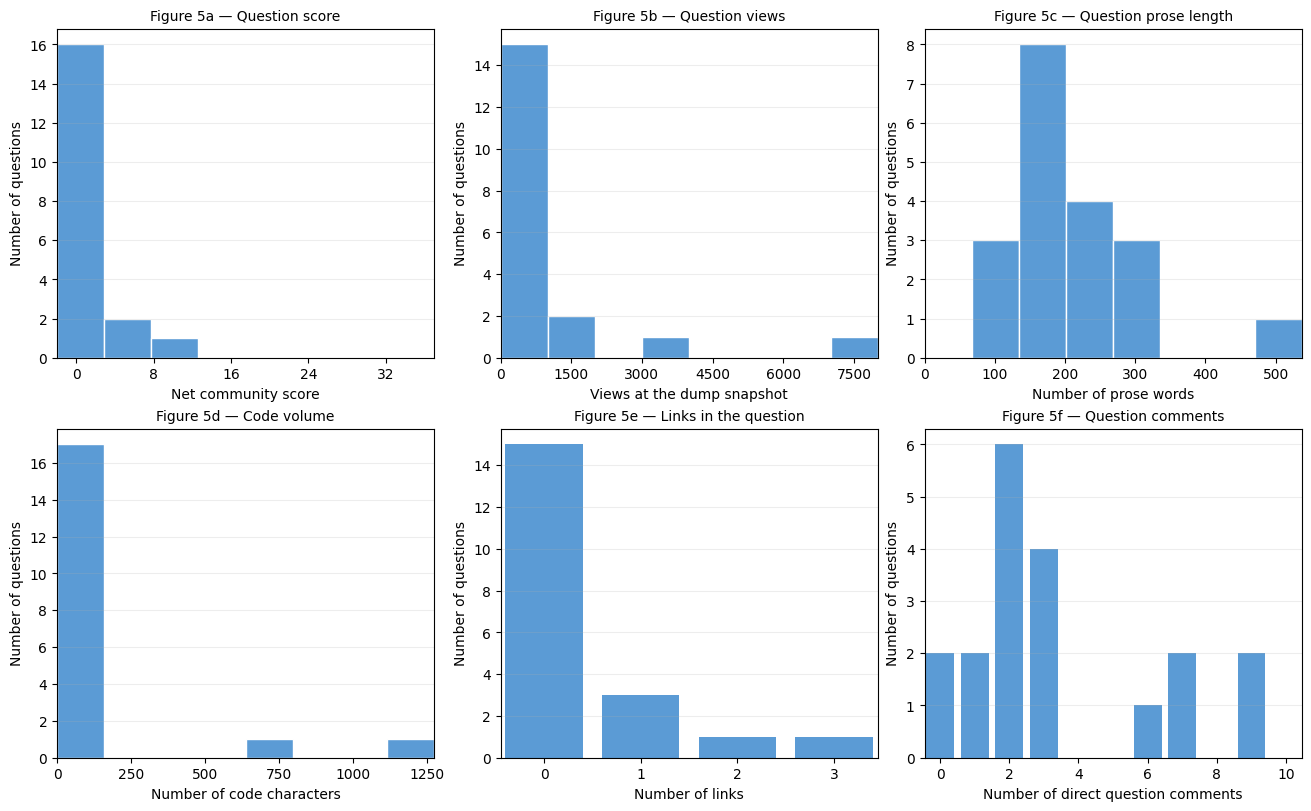

**Figure 5 interpretation**  
- **Figure 5a — Question score:** 20 values; median **1.0**; shown range **-2.0 to 37.0**; values below/above the range **0/1**; observed minimum/maximum **-2.0/42.0**.  
- **Figure 5b — Question views:** 20 values; median **592.5**; shown range **0.0 to 8,002.0**; values below/above the range **0/1**; observed minimum/maximum **150.0/12,103.0**.  
- **Figure 5c — Question prose length:** 20 values; median **190.5**; shown range **0.0 to 537.0**; values below/above the range **0/1**; observed minimum/maximum **68.0/568.0**.  
- **Figure 5d — Code volume:** 20 values; median **0.0**; shown range **0.0 to 1,273.0**; values below/above the range **0/1**; observed minimum/maximum **0.0/1,357.0**.  
- **Figure 5e — Links in the question:** 20 values; median **0.0**; shown range **0.0 to 3.0**; values below/above the range **0/0**; observed minimum/maximum **0.0/3.0**.  
- **Figure 5f — Question comments:** 20 values; median **2.5**; shown range **0.0 to 10.0**; values below/above the range **0/1**; observed minimum/maximum **0.0/11.0**.

In [23]:
# Figure 5: content and interaction measurements.
fig, axes = plt.subplots(2, 3, figsize=(13, 8), layout="constrained")
figure_5_results = []
for ax, (subfigure, title, x_label, column, whole, low_q, high_q) in zip(axes.flat, content_specs):
    result = draw_distribution(
        ax, data[column], f"Figure {subfigure} — {title}", x_label,
        whole_numbers=whole, lower_quantile=low_q, upper_quantile=high_q,
    )
    figure_5_results.append((subfigure, title, result))
plt.show()

lines = []
for subfigure, title, result in figure_5_results:
    if result is None:
        lines.append(f"- **Figure {subfigure} — {title}:** no value is available.")
        continue
    lines.append(
        f"- **Figure {subfigure} — {title}:** {result['available']:,} values; median **{result['median']:,.1f}**; "
        f"shown range **{result['lower']:,.1f} to {result['upper']:,.1f}**; "
        f"values below/above the range **{result['below']:,}/{result['above']:,}**; "
        f"observed minimum/maximum **{result['minimum']:,.1f}/{result['maximum']:,.1f}**."
    )
display(Markdown("**Figure 5 interpretation**  \n" + "  \n".join(lines)))
figure_status.append({"Figure": "5", "Status": "Produced", "Evidence": "Six content and interaction distributions"})

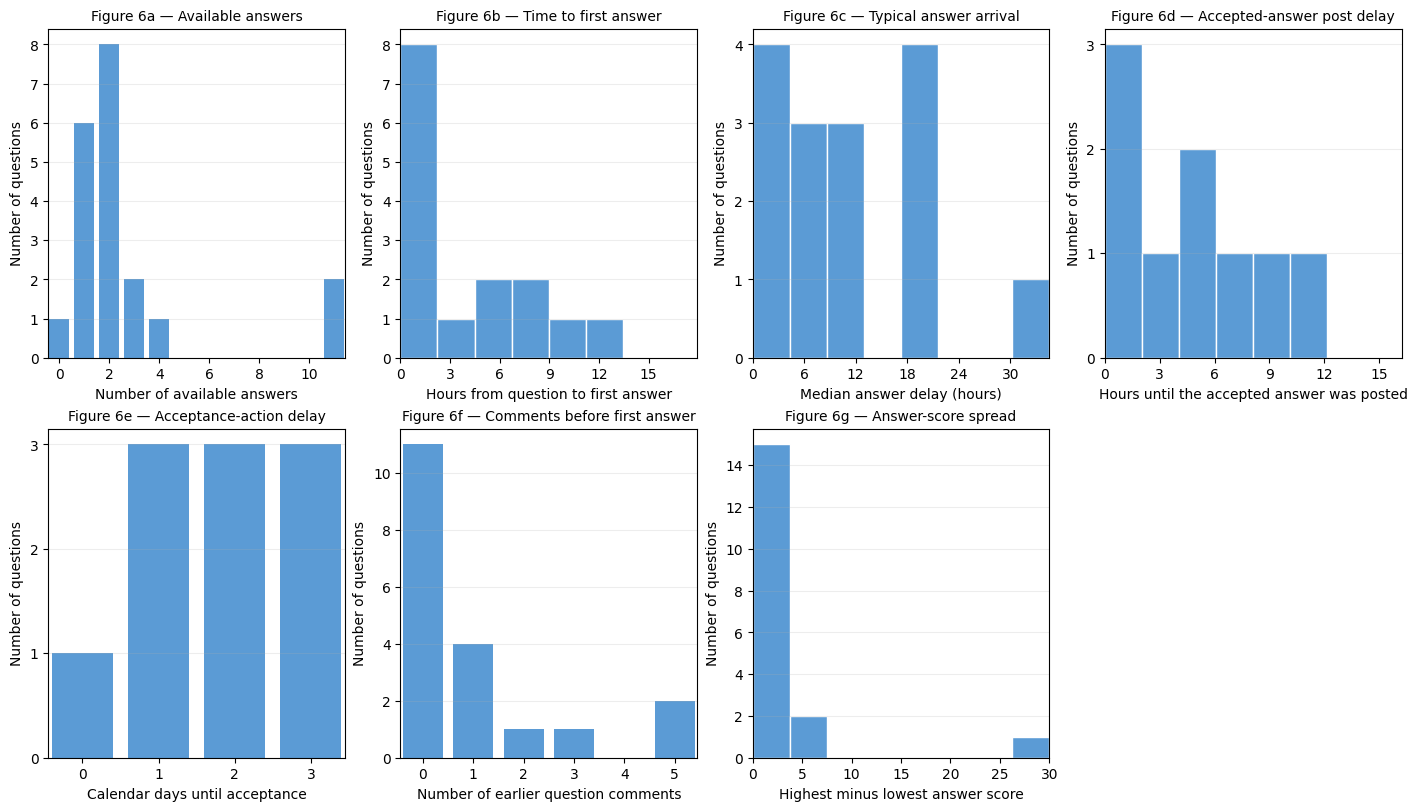

**Figure 6 interpretation**  
- **Figure 6a — Available answers:** 20 values; median **2.0**; shown range **0.0 to 11.0**; values below/above the range **0/0**; observed minimum/maximum **0.0/11.0**.  
- **Figure 6b — Time to first answer:** 19 values; median **5.1**; shown range **0.0 to 17.9**; values below/above the range **0/4**; observed minimum/maximum **0.1/395.6**.  
- **Figure 6c — Typical answer arrival:** 19 values; median **12.8**; shown range **0.0 to 34.6**; values below/above the range **0/4**; observed minimum/maximum **0.8/395.6**.  
- **Figure 6d — Accepted-answer post delay:** 12 values; median **6.1**; shown range **0.0 to 16.2**; values below/above the range **0/3**; observed minimum/maximum **0.3/95.9**.  
- **Figure 6e — Acceptance-action delay:** 12 values; median **2.0**; shown range **0.0 to 3.0**; values below/above the range **0/2**; observed minimum/maximum **0.0/12.0**.  
- **Figure 6f — Comments before first answer:** 19 values; median **0.0**; shown range **0.0 to 5.0**; values below/above the range **0/0**; observed minimum/maximum **0.0/5.0**.  
- **Figure 6g — Answer-score spread:** 19 values; median **1.0**; shown range **0.0 to 30.0**; values below/above the range **0/1**; observed minimum/maximum **0.0/44.0**.

In [24]:
# Figure 6: response and resolution measurements.
fig, axes = plt.subplots(2, 4, figsize=(14, 8), layout="constrained")
figure_6_results = []
for ax, (subfigure, title, x_label, column, whole, low_q, high_q) in zip(axes.flat, response_specs):
    result = draw_distribution(
        ax, data[column], f"Figure {subfigure} — {title}", x_label,
        whole_numbers=whole, lower_quantile=low_q, upper_quantile=high_q,
    )
    figure_6_results.append((subfigure, title, result))
axes.flat[-1].set_axis_off()
plt.show()

lines = []
for subfigure, title, result in figure_6_results:
    if result is None:
        lines.append(f"- **Figure {subfigure} — {title}:** no value is available because the corresponding event is absent.")
        continue
    lines.append(
        f"- **Figure {subfigure} — {title}:** {result['available']:,} values; median **{result['median']:,.1f}**; "
        f"shown range **{result['lower']:,.1f} to {result['upper']:,.1f}**; "
        f"values below/above the range **{result['below']:,}/{result['above']:,}**; "
        f"observed minimum/maximum **{result['minimum']:,.1f}/{result['maximum']:,.1f}**."
    )
display(Markdown("**Figure 6 interpretation**  \n" + "  \n".join(lines)))
figure_status.append({"Figure": "6", "Status": "Produced", "Evidence": "Seven response and resolution distributions"})

## 7. Figure 7 — Tukey high-outlier evidence

**Question notation.** (Q_i) denotes the question represented by row (i). Its outlier status comes from the values recorded for the numeric measurements listed below.

**Method.** Tukey's high-outlier rule uses the third quartile plus 1.5 times the interquartile range. The interquartile range is the distance from the 25th percentile (`Q1`) to the 75th percentile (`Q3`). A value above the resulting threshold receives a high-outlier flag for that measurement.

**Interpretation.** Figure 7 compares the percentage of questions above each measurement-specific threshold. The table reports the quartiles, threshold, and exact count. A statistical outlier is an inspection candidate; data-error and difficulty classifications require separate evidence.

In [25]:
# Tukey thresholds and row-level flags.
outlier_labels = {
    "question_view_count": "Question views",
    "question_word_count": "Question prose words",
    "code_character_count": "Code characters",
    "available_answer_count": "Available answers",
    "available_question_comment_count": "Question comments",
    "time_to_first_answer_hours": "Hours to first answer",
    "time_to_eventually_accepted_answer_post_hours": "Hours to accepted-answer post",
    "answer_score_spread": "Answer-score spread",
}
outlier_flags = pd.DataFrame(False, index=data.index, columns=outlier_labels)
outlier_rows = []
for column, label in outlier_labels.items():
    values = data[column].dropna()
    if values.empty:
        q1 = q3 = threshold = np.nan
        count = 0
    else:
        q1, q3 = values.quantile([0.25, 0.75])
        threshold = q3 + 1.5 * (q3 - q1)
        outlier_flags[column] = data[column].gt(threshold).fillna(False)
        count = int(outlier_flags[column].sum())
    outlier_rows.append({
        "Measurement": label, "Available values": len(values),
        "Q1 (25th percentile)": q1, "Q3 (75th percentile)": q3,
        "High-outlier threshold": threshold, "High outliers": count,
        "Share of all questions (%)": 100 * count / len(data),
    })

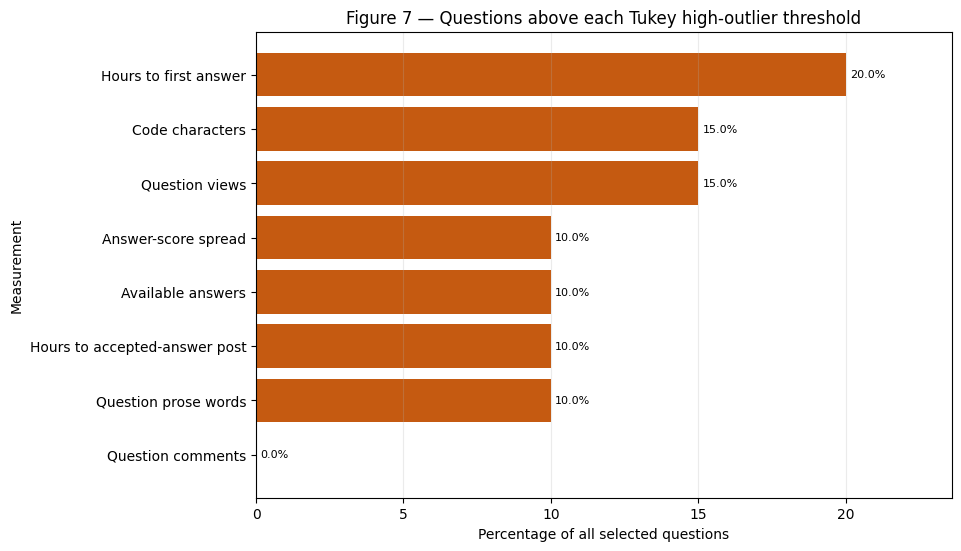

,Measurement,Available values,Q1 (25th percentile),Q3 (75th percentile),High-outlier threshold,High outliers,Share of all questions (%)
7,Answer-score spread,19,0.0,3.0,7.5,2,10.0
3,Available answers,20,1.0,2.2,4.1,2,10.0
2,Code characters,20,0.0,62.2,155.6,3,15.0
6,Hours to accepted-answer post,12,1.7,13.2,30.3,2,10.0
5,Hours to first answer,19,1.3,10.5,24.3,4,20.0
4,Question comments,20,2.0,6.2,12.6,0,0.0
1,Question prose words,20,153.0,268.2,441.1,2,10.0
0,Question views,20,316.5,957.8,1919.6,3,15.0


**Figure 7 interpretation**  
- **Hours to first answer** has the largest high-outlier share: **4 questions (20.0%)**.  
- Each measurement has its own threshold because units and distributions differ.  
- The separate outlier dataset links these flags to complete question rows.

In [26]:
# Figure 7 and its threshold table.
outlier_summary = pd.DataFrame(outlier_rows).sort_values("Share of all questions (%)")
fig, ax = plt.subplots(figsize=(9.5, 5.4), layout="constrained")
bars = ax.barh(outlier_summary["Measurement"], outlier_summary["Share of all questions (%)"], color="#C55A11")
ax.set_title("Figure 7 — Questions above each Tukey high-outlier threshold")
ax.set_xlabel("Percentage of all selected questions")
ax.set_ylabel("Measurement")
ax.grid(axis="x", alpha=0.25)
ax.bar_label(bars, labels=[f"{value:.1f}%" for value in outlier_summary["Share of all questions (%)"]], padding=3, fontsize=8)
ax.set_xlim(0, max(1, outlier_summary["Share of all questions (%)"].max() * 1.18))
plt.show()

display(outlier_summary.sort_values("Measurement").round({
    "Q1 (25th percentile)": 1, "Q3 (75th percentile)": 1,
    "High-outlier threshold": 1, "Share of all questions (%)": 1,
}))
largest_outlier_group = outlier_summary.iloc[-1]
display(Markdown(
    "**Figure 7 interpretation**  \n"
    f"- **{largest_outlier_group['Measurement']}** has the largest high-outlier share: "
    f"**{int(largest_outlier_group['High outliers']):,} questions ({largest_outlier_group['Share of all questions (%)']:.1f}%)**.  \n"
    "- Each measurement has its own threshold because units and distributions differ.  \n"
    "- The separate outlier dataset links these flags to complete question rows."
))
figure_status.append({"Figure": "7", "Status": "Produced", "Evidence": f"{len(outlier_summary)} Tukey thresholds"})

In [27]:
# Separate question-level outlier dataset and optional TSV export.
data["high_outlier_field_count"] = outlier_flags.sum(axis=1)

def outlier_reason(row_index):
    """Returns the high-outlier measurement labels for one question."""
    labels = [outlier_labels[column] for column in outlier_labels if outlier_flags.loc[row_index, column]]
    return "; ".join(labels)

data["high_outlier_measurements"] = [outlier_reason(index) for index in data.index]
outlier_questions = data.loc[
    data["high_outlier_field_count"].gt(0),
    source_columns + ["high_outlier_field_count", "high_outlier_measurements"],
].copy()

if OUTLIER_OUTPUT_FILE is None:
    outlier_export_status = "In-memory dataset: outlier_questions"
else:
    OUTLIER_OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
    outlier_questions.to_csv(OUTLIER_OUTPUT_FILE, sep="\t", index=False)
    outlier_export_status = f"Written TSV: {OUTLIER_OUTPUT_FILE}"

display(Markdown(
    f"**Separate outlier dataset:** **{len(outlier_questions):,}** questions × "
    f"**{len(outlier_questions.columns):,}** columns. {outlier_export_status}."
))

**Separate outlier dataset:** **13** questions × **51** columns. In-memory dataset: outlier_questions.

## 8. Figure 8 — Patterns in the separate outlier dataset

This section compares all selected questions with questions carrying at least one Tukey high-outlier flag. Figure 8a compares answered, accepted, and closed percentages. Figure 8b reports frequent tags within the outlier subset. The accompanying table compares medians in their original units.

These results identify patterns for qualitative investigation. Differences between the groups do not establish a cause for outlier behavior.

In [28]:
# Outcome percentages, median measurements, and tags for outlier EDA.
outcome_comparison = pd.DataFrame({
    "Outcome": ["Received an answer", "Has an accepted answer", "Closed"],
    "All selected questions": [
        100 * data["has_available_answer"].mean(),
        100 * data["has_accepted_answer"].mean(),
        100 * data["is_closed"].mean(),
    ],
    "High-outlier questions": [
        100 * outlier_questions["has_available_answer"].mean(),
        100 * outlier_questions["accepted_answer_id"].notna().mean(),
        100 * outlier_questions["closed_datetime"].notna().mean(),
    ],
})

comparison_fields = {
    "question_view_count": "Question views",
    "question_word_count": "Question prose words",
    "available_answer_count": "Available answers",
    "available_question_comment_count": "Question comments",
    "time_to_first_answer_hours": "Hours to first answer",
}
median_comparison = pd.DataFrame({
    "Measurement": comparison_fields.values(),
    "Median — all selected questions": [data[column].median() for column in comparison_fields],
    "Median — high-outlier questions": [outlier_questions[column].median() for column in comparison_fields],
})

outlier_tag_rows = outlier_questions[["question_id", "question_tags"]].dropna().copy()
outlier_tag_rows["tag"] = outlier_tag_rows["question_tags"].str.split(";")
outlier_tag_rows = outlier_tag_rows.explode("tag")
outlier_tag_rows["tag"] = outlier_tag_rows["tag"].str.strip()
outlier_tag_frequency = outlier_tag_rows.loc[outlier_tag_rows["tag"].ne(""), "tag"].value_counts().head(10).sort_values()

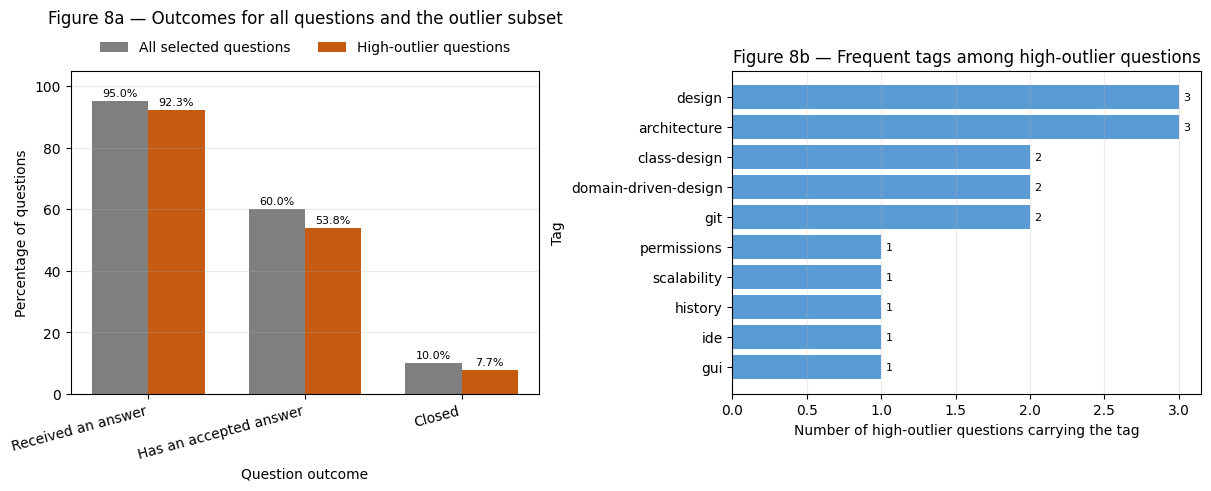

,Measurement,Median — all selected questions,Median — high-outlier questions
0,Question views,592.5,619.0
1,Question prose words,190.5,181.0
2,Available answers,2.0,2.0
3,Question comments,2.5,2.0
4,Hours to first answer,5.1,5.1


**Figure 8 interpretation**  
- The separate dataset contains **13 of 20 selected questions (65.0%)**.  
- The largest displayed outcome difference concerns **Has an accepted answer**: **60.0%** overall and **53.8%** in the outlier subset.  
- The most frequent available outlier-subset tag is **design**.

In [29]:
if outlier_questions.empty:
    display(Markdown("**Figure 8 is unavailable.** No selected question carries a Tukey high-outlier flag."))
    figure_status.append({"Figure": "8", "Status": "Unavailable", "Evidence": "No high-outlier question"})
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), layout="constrained")
    positions = np.arange(len(outcome_comparison))
    width = 0.36
    first_bars = axes[0].bar(positions - width / 2, outcome_comparison["All selected questions"], width, label="All selected questions", color="#7F7F7F")
    second_bars = axes[0].bar(positions + width / 2, outcome_comparison["High-outlier questions"], width, label="High-outlier questions", color="#C55A11")
    axes[0].set_xticks(positions, outcome_comparison["Outcome"], rotation=15, ha="right")
    axes[0].set_title("Figure 8a — Outcomes for all questions and the outlier subset", pad=34)
    axes[0].set_xlabel("Question outcome")
    axes[0].set_ylabel("Percentage of questions")
    axes[0].set_ylim(0, 105)
    axes[0].grid(axis="y", alpha=0.25)
    axes[0].legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.01), ncols=2)
    axes[0].bar_label(first_bars, fmt="%.1f%%", padding=2, fontsize=8)
    axes[0].bar_label(second_bars, fmt="%.1f%%", padding=2, fontsize=8)

    if outlier_tag_frequency.empty:
        axes[1].text(0.5, 0.5, "No tags are available in the outlier subset", ha="center", va="center")
        axes[1].set_axis_off()
    else:
        tag_bars = axes[1].barh(outlier_tag_frequency.index, outlier_tag_frequency.values, color="#5B9BD5")
        axes[1].set_title("Figure 8b — Frequent tags among high-outlier questions")
        axes[1].set_xlabel("Number of high-outlier questions carrying the tag")
        axes[1].set_ylabel("Tag")
        axes[1].grid(axis="x", alpha=0.25)
        axes[1].bar_label(tag_bars, padding=3, fontsize=8)
    plt.show()

    display(median_comparison.round(1))
    largest_gap_row = outcome_comparison.loc[
        (outcome_comparison["High-outlier questions"] - outcome_comparison["All selected questions"]).abs().idxmax()
    ]
    top_outlier_tag = outlier_tag_frequency.index[-1] if not outlier_tag_frequency.empty else "Unavailable"
    display(Markdown(
        "**Figure 8 interpretation**  \n"
        f"- The separate dataset contains **{len(outlier_questions):,} of {len(data):,} selected questions ({len(outlier_questions) / len(data):.1%})**.  \n"
        f"- The largest displayed outcome difference concerns **{largest_gap_row['Outcome']}**: "
        f"**{largest_gap_row['All selected questions']:.1f}%** overall and **{largest_gap_row['High-outlier questions']:.1f}%** in the outlier subset.  \n"
        f"- The most frequent available outlier-subset tag is **{top_outlier_tag}**."
    ))
    figure_status.append({"Figure": "8", "Status": "Produced", "Evidence": f"{len(outlier_questions)} high-outlier questions"})

## 9. Figure 9 — Curated Spearman relationships

**Definition.** Spearman correlation measures whether two characteristics tend to rise or fall together after replacement of raw values with ranks.

**Interpretation.** Values approach `1` when both characteristics rise together, `−1` when one rises as the other falls, and `0` when ranked movement has little consistent pattern.

Each pair requires at least `MIN_CORRELATION_OBSERVATIONS` complete rows. Displayed pairs also satisfy the `MIN_ABSOLUTE_RHO` strength rule and the Benjamini–Hochberg `FDR_ALPHA` false-discovery-rate rule. Each heatmap row represents one retained pair, which removes mirrored duplicates, the diagonal, and unused matrix space. Correlation supports investigation; causal conclusions require a separate study.

In [30]:
# Exhaustive pair calculation for a curated set of interpretable measurements.
correlation_labels = {
    "question_word_count": "Prose words",
    "code_character_count": "Code characters",
    "link_count": "Links",
    "image_count": "Images",
    "tag_count": "Tags",
    "question_score": "Question score",
    "question_view_count": "Views",
    "available_answer_count": "Available answers",
    "available_question_comment_count": "Question comments",
    "comments_before_first_answer": "Comments before first answer",
    "time_to_first_answer_hours": "Hours to first answer",
    "median_answer_response_hours": "Median answer delay",
    "time_to_eventually_accepted_answer_post_hours": "Hours to accepted-answer post",
    "days_to_acceptance": "Days to acceptance",
    "answer_score_spread": "Answer-score spread",
    "observation_days_at_dump": "Observation days",
}
structural_pairs = {frozenset(("link_count", "image_count"))}
pair_results = []
for first, second in combinations(correlation_labels, 2):
    if frozenset((first, second)) in structural_pairs:
        continue
    pair = data[[first, second]].dropna()
    if len(pair) < MIN_CORRELATION_OBSERVATIONS:
        continue
    if pair[first].nunique() < 2 or pair[second].nunique() < 2:
        continue
    rho, p_value = stats.spearmanr(pair[first], pair[second])
    pair_results.append({
        "first": first, "second": second, "rho": rho,
        "p_value": p_value, "observations": len(pair),
    })

correlations = pd.DataFrame(pair_results)
if correlations.empty:
    meaningful = correlations.copy()
else:
    correlations["q_value"] = stats.false_discovery_control(correlations["p_value"].to_numpy(), method="bh")
    meaningful = correlations[
        (correlations["rho"].abs() >= MIN_ABSOLUTE_RHO)
        & (correlations["q_value"] <= FDR_ALPHA)
    ].copy()

In [31]:
if meaningful.empty:
    display(Markdown(
        "**Figure 9 is unavailable.** No pair satisfies the sample-size, strength, "
        "and false-discovery-rate rules in this table."
    ))
    figure_status.append({"Figure": "9", "Status": "Unavailable", "Evidence": "No pair passed all rules"})
else:
    meaningful["pair_label"] = [
        f"{correlation_labels[first]}  ↔  {correlation_labels[second]}"
        for first, second in zip(meaningful["first"], meaningful["second"])
    ]
    meaningful = meaningful.reindex(meaningful["rho"].abs().sort_values(ascending=False).index)
    figure_height = min(10, max(3.2, 1.4 + 0.38 * len(meaningful)))
    fig, ax = plt.subplots(figsize=(7.8, figure_height), layout="constrained")
    image = ax.imshow(meaningful[["rho"]].to_numpy(), aspect="auto", vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_yticks(range(len(meaningful)), meaningful["pair_label"])
    ax.set_xticks([0], ["rho"])
    ax.set_xlabel("Spearman correlation coefficient")
    ax.set_ylabel("Characteristic pair")
    ax.set_title("Figure 9 — Meaningful Spearman relationships")
    for row_number, rho in enumerate(meaningful["rho"]):
        ax.text(0, row_number, f"{rho:.2f}", ha="center", va="center")
    color_bar = fig.colorbar(image, ax=ax, shrink=0.82)
    color_bar.set_label("Relationship direction and strength")
    plt.show()

    lines = []
    for row in meaningful.head(4).itertuples():
        direction = "rise together" if row.rho > 0 else "move in opposite directions"
        q_text = "< 1e-300" if row.q_value == 0 else f"{row.q_value:.3g}"
        lines.append(
            f"- **{correlation_labels[row.first]}** and **{correlation_labels[row.second]}** "
            f"{direction} (rho = {row.rho:.2f}; q-value {q_text}; complete questions = {row.observations:,})."
        )
    display(Markdown(
        "**Figure 9 interpretation**  \n" + "  \n".join(lines)
        + "  \n- These relationships identify hypotheses and cases for closer analysis."
    ))
    figure_status.append({"Figure": "9", "Status": "Produced", "Evidence": f"{len(meaningful)} retained pairs"})

**Figure 9 is unavailable.** No pair satisfies the sample-size, strength, and false-discovery-rate rules in this table.

## 10. Figure 10 — Tags and response outcomes

A tag names a question topic. One question can carry several tags, so tag totals overlap.

Figure 10a gives exact counts for all questions carrying each frequent tag, including answered, unanswered, accepted, and closed questions. Figure 10b compares outcome percentages for tags supported by at least `MIN_TAG_QUESTIONS` questions. The accompanying table preserves the exact counts behind both panels.

In [32]:
# Tag frequencies, exact outcome counts, and percentages.
tag_rows = data[["question_id", "question_tags"]].dropna(subset=["question_tags"]).copy()
tag_rows["tag"] = tag_rows["question_tags"].str.split(";")
tag_rows = tag_rows.explode("tag")
tag_rows["tag"] = tag_rows["tag"].str.strip()
tag_rows = tag_rows[tag_rows["tag"].ne("")].drop_duplicates(["question_id", "tag"])

tag_outcomes = tag_rows.merge(
    data[["question_id", "has_available_answer", "has_accepted_answer", "is_closed"]],
    on="question_id", how="left",
)
tag_summary = tag_outcomes.groupby("tag").agg(
    questions=("question_id", "nunique"),
    answered_questions=("has_available_answer", "sum"),
    accepted_questions=("has_accepted_answer", "sum"),
    closed_questions=("is_closed", "sum"),
)
tag_summary["unanswered_questions"] = tag_summary["questions"] - tag_summary["answered_questions"]
tag_summary["answered_percentage"] = 100 * tag_summary["answered_questions"] / tag_summary["questions"]
tag_summary["accepted_percentage"] = 100 * tag_summary["accepted_questions"] / tag_summary["questions"]
tag_summary["closed_percentage"] = 100 * tag_summary["closed_questions"] / tag_summary["questions"]

top_tags = tag_summary.sort_values(["questions"], ascending=False).head(TOP_TAGS_TO_SHOW).sort_values("questions")
eligible_tags = tag_summary[tag_summary["questions"] >= MIN_TAG_QUESTIONS]
eligible_tags = eligible_tags.sort_values("questions", ascending=False).head(TOP_TAGS_TO_SHOW)
eligible_tags = eligible_tags.sort_values("answered_percentage")

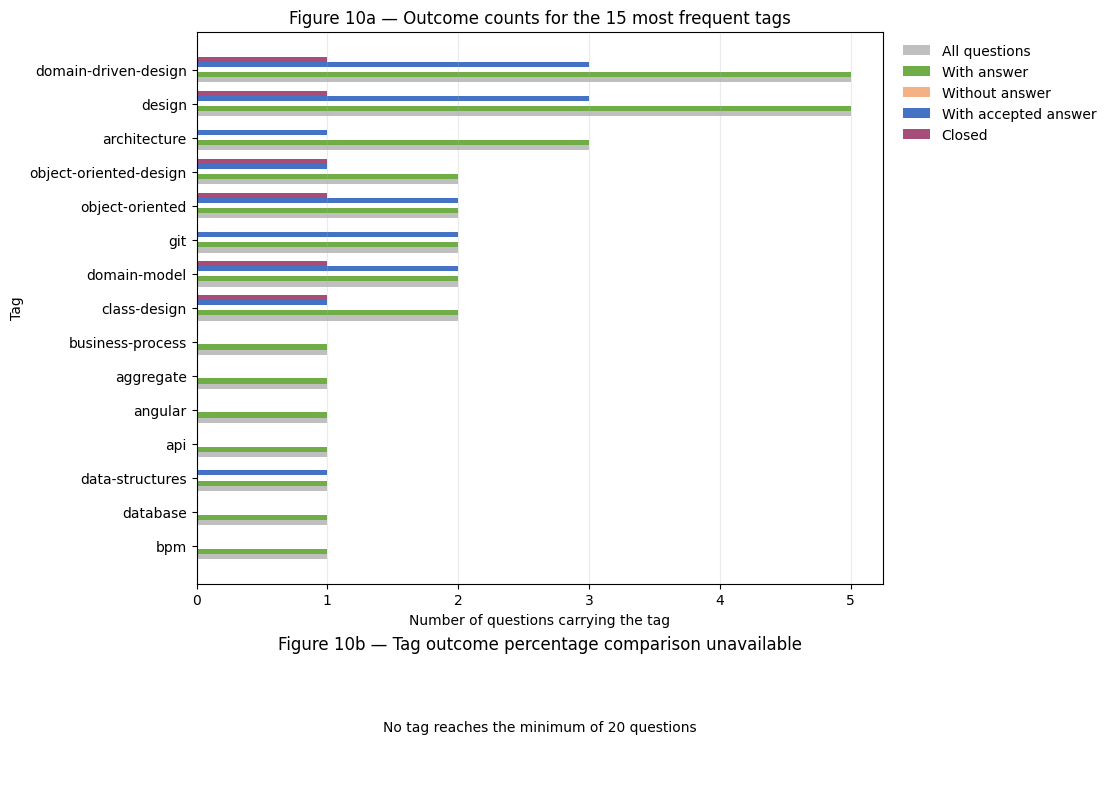

In [33]:
# Figure 10 count and percentage panels.
if eligible_tags.empty:
    figure_height = min(9.0, max(6.8, 4.5 + 0.23 * len(top_tags)))
    height_ratios = [4, 1]
else:
    figure_height = min(11.5, max(8.5, 4.2 + 0.23 * (len(top_tags) + len(eligible_tags))))
    height_ratios = [max(4, len(top_tags)), max(4, len(eligible_tags))]
fig, axes = plt.subplots(2, 1, figsize=(11, figure_height), gridspec_kw={"height_ratios": height_ratios}, layout="constrained")

if top_tags.empty:
    axes[0].text(0.5, 0.5, "No question tags are available", ha="center", va="center")
    axes[0].set_axis_off()
else:
    positions = np.arange(len(top_tags))
    count_columns = ["questions", "answered_questions", "unanswered_questions", "accepted_questions", "closed_questions"]
    count_labels = ["All questions", "With answer", "Without answer", "With accepted answer", "Closed"]
    count_colors = ["#BFBFBF", "#70AD47", "#F4B183", "#4472C4", "#A64D79"]
    bar_height = 0.15
    for offset, (column, label, color) in enumerate(zip(count_columns, count_labels, count_colors)):
        axes[0].barh(positions + (offset - 2) * bar_height, top_tags[column], height=bar_height, label=label, color=color)
    axes[0].set_yticks(positions, top_tags.index)
    axes[0].set_title(f"Figure 10a — Outcome counts for the {len(top_tags)} most frequent tags")
    axes[0].set_xlabel("Number of questions carrying the tag")
    axes[0].set_ylabel("Tag")
    axes[0].grid(axis="x", alpha=0.25)
    axes[0].legend(frameon=False, ncols=1, loc="upper left", bbox_to_anchor=(1.01, 1))

if eligible_tags.empty:
    axes[1].text(0.5, 0.5, f"No tag reaches the minimum of {MIN_TAG_QUESTIONS} questions", ha="center", va="center")
    axes[1].set_title("Figure 10b — Tag outcome percentage comparison unavailable")
    axes[1].set_axis_off()
else:
    positions = np.arange(len(eligible_tags))
    axes[1].barh(positions - 0.24, eligible_tags["answered_percentage"], height=0.24, label="At least one answer")
    axes[1].barh(positions, eligible_tags["accepted_percentage"], height=0.24, label="Accepted answer")
    axes[1].barh(positions + 0.24, eligible_tags["closed_percentage"], height=0.24, label="Closed")
    tag_axis_labels = [f"{tag} (n={int(eligible_tags.loc[tag, 'questions'])})" for tag in eligible_tags.index]
    axes[1].set_yticks(positions, tag_axis_labels)
    axes[1].set_xlim(0, 100)
    axes[1].set_title(f"Figure 10b — Outcome percentages for tags with at least {MIN_TAG_QUESTIONS} questions")
    axes[1].set_xlabel("Percentage of questions carrying the tag")
    axes[1].set_ylabel("Tag")
    axes[1].grid(axis="x", alpha=0.25)
    axes[1].legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.show()

In [34]:
# Exact tag counts and Figure 10 interpretation.
if not top_tags.empty:
    tag_table = top_tags.sort_values("questions", ascending=False).reset_index().rename(columns={
        "tag": "Tag", "questions": "Questions", "answered_questions": "With answer",
        "unanswered_questions": "Without answer", "accepted_questions": "With accepted answer",
        "closed_questions": "Closed", "answered_percentage": "Answered (%)",
        "accepted_percentage": "Accepted (%)", "closed_percentage": "Closed (%)",
    })
    display(tag_table.round(1))

if top_tags.empty:
    display(Markdown("**Figure 10 interpretation.** The selected table contains no available tags."))
    figure_status.append({"Figure": "10", "Status": "Unavailable", "Evidence": "No tags"})
elif eligible_tags.empty:
    most_frequent = tag_summary["questions"].idxmax()
    display(Markdown(
        f"**Figure 10 interpretation.** **{most_frequent}** is the most frequent tag "
        f"({int(tag_summary.loc[most_frequent, 'questions']):,} questions). Exact outcome counts are available; "
        f"percentage comparison requires at least {MIN_TAG_QUESTIONS} questions per tag."
    ))
    figure_status.append({"Figure": "10", "Status": "Partial", "Evidence": "Tag counts available; no eligible percentage groups"})
else:
    highest = eligible_tags["answered_percentage"].idxmax()
    lowest = eligible_tags["answered_percentage"].idxmin()
    most_frequent = tag_summary["questions"].idxmax()
    display(Markdown(
        f"**Figure 10 interpretation.** **{most_frequent}** is the most frequent tag "
        f"({int(tag_summary.loc[most_frequent, 'questions']):,} questions). Among eligible tags, "
        f"**{highest}** has the highest answered share ({eligible_tags.loc[highest, 'answered_percentage']:.1f}%) "
        f"and **{lowest}** has the lowest ({eligible_tags.loc[lowest, 'answered_percentage']:.1f}%)."
    ))
    figure_status.append({"Figure": "10", "Status": "Produced", "Evidence": f"{len(top_tags)} frequent and {len(eligible_tags)} eligible tags"})

,Tag,Questions,With answer,With accepted answer,Closed,Without answer,Answered (%),Accepted (%),Closed (%)
0,design,5,5,3,1,0,100.0,60.0,20.0
1,domain-driven-design,5,5,3,1,0,100.0,60.0,20.0
2,architecture,3,3,1,0,0,100.0,33.3,0.0
3,class-design,2,2,1,1,0,100.0,50.0,50.0
4,domain-model,2,2,2,1,0,100.0,100.0,50.0
5,git,2,2,2,0,0,100.0,100.0,0.0
6,object-oriented,2,2,2,1,0,100.0,100.0,50.0
7,object-oriented-design,2,2,1,1,0,100.0,50.0,50.0
8,business-process,1,1,0,0,0,100.0,0.0,0.0
9,angular,1,1,0,0,0,100.0,0.0,0.0


**Figure 10 interpretation.** **design** is the most frequent tag (5 questions). Exact outcome counts are available; percentage comparison requires at least 20 questions per tag.

## 11. High-outlier questions selected for inspection

The table links Tukey flags to concrete questions from the separate outlier dataset. Rows with several flagged measurements receive priority, followed by long first-answer delays and high question-comment counts. These entries support qualitative inspection. Difficulty labels require a documented manual assessment.

In [35]:
if outlier_questions.empty:
    display(Markdown("No high-outlier question is available for the final inspection table."))
else:
    cases = outlier_questions.sort_values(
        ["high_outlier_field_count", "time_to_first_answer_hours", "available_question_comment_count"],
        ascending=[False, False, False], na_position="last",
    ).head(MAX_CASES_TO_SHOW).copy()
    cases["question_title"] = cases["question_title"].fillna("").str.slice(0, 90)
    cases_to_show = cases[[
        "high_outlier_measurements", "high_outlier_field_count", "question_id", "question_title",
        "question_url", "available_answer_count", "available_question_comment_count",
        "time_to_first_answer_hours",
    ]].rename(columns={
        "high_outlier_measurements": "High-outlier measurements",
        "high_outlier_field_count": "Tukey flags",
        "question_id": "Question ID",
        "question_title": "Question title (first 90 characters)",
        "question_url": "Question URL",
        "available_answer_count": "Available answers",
        "available_question_comment_count": "Question comments",
        "time_to_first_answer_hours": "Hours to first answer",
    })
    display(cases_to_show)

,High-outlier measurements,Tukey flags,Question ID,Question title (first 90 characters),Question URL,Available answers,Question comments,Hours to first answer
8,Question views; Available answers; Answer-scor...,3,450386,Where to keep the code that I do not want in t...,https://softwareengineering.stackexchange.com/...,11,7,0.251918
7,Question views; Available answers; Answer-scor...,3,450379,What do you do with branches you've abandoned?,https://softwareengineering.stackexchange.com/...,11,2,0.143861
2,Hours to first answer; Hours to accepted-answe...,2,450359,Offering multiple versions of artifact heavy p...,https://softwareengineering.stackexchange.com/...,2,1,35.570644
1,Hours to first answer,1,450356,How to make a hierarchical permission architec...,https://softwareengineering.stackexchange.com/...,1,3,395.622293
12,Hours to first answer,1,450414,Orchestrator (like Camunda) between frontend a...,https://softwareengineering.stackexchange.com/...,2,3,30.985681
4,Hours to first answer,1,450361,Splitting up large SQLAlchemy model,https://softwareengineering.stackexchange.com/...,2,1,27.169258
6,Code characters,1,450374,Should domain services in a domain-driven desi...,https://softwareengineering.stackexchange.com/...,1,2,9.218981
0,Hours to accepted-answer post,1,450355,What was the first company to make a drag-and-...,https://softwareengineering.stackexchange.com/...,3,9,7.690655


## 12. Run status and result applications

- Figures 1–3 describe table quality, posting-period outcomes, and cumulative event evolution.
- Figure 4 follows first-response acquisition for every posting-month cohort.
- Figures 5–7 describe content, response, resolution, and Tukey high-outlier evidence.
- Figure 8 examines patterns in the separate outlier dataset.
- Figure 9 reports statistically supported associations when sufficient evidence is available.
- Figure 10 provides tag-level outcome counts and percentages.
- Section 11 provides concrete high-outlier questions for qualitative inspection.
- Human and model difficulty require separate documented evaluation protocols.

In [36]:
# Final evidence that every preceding cell completed.
status_table = pd.DataFrame(figure_status)
display(status_table)

produced = int((status_table["Status"] == "Produced").sum())
partial = int((status_table["Status"] == "Partial").sum())
unavailable = int((status_table["Status"] == "Unavailable").sum())
display(Markdown(
    "**Run complete.**  \n"
    f"- Input file: `{DATA_FILE}`  \n"
    f"- Source table: **{source_row_count:,} rows × {source_column_count:,} columns**  \n"
    f"- Selected period: **{requested_period}**  \n"
    f"- Questions analyzed: **{len(data):,}**  \n"
    f"- Separate high-outlier dataset: **{len(outlier_questions):,} questions**  \n"
    f"- Outlier export: **{outlier_export_status}**  \n"
    f"- Figure groups produced: **{produced}**  \n"
    f"- Figure groups partially available: **{partial}**  \n"
    f"- Figure groups unavailable because evidence was insufficient: **{unavailable}**  \n"
    "- Execution reached the final cell without a notebook exception."
))

,Figure,Status,Evidence
0,1,Produced,"Outcome, availability, and consistency checks"
1,2,Produced,1 months and 1 years
2,3,Produced,28 cumulative calendar months
3,4,Produced,1 posting-month cohorts
4,5,Produced,Six content and interaction distributions
5,6,Produced,Seven response and resolution distributions
6,7,Produced,8 Tukey thresholds
7,8,Produced,13 high-outlier questions
8,9,Unavailable,No pair passed all rules
9,10,Partial,Tag counts available; no eligible percentage g...


**Run complete.**  
- Input file: `../data/examples/characteristics_pilot.tsv`  
- Source table: **20 rows × 49 columns**  
- Selected period: **All question rows in the TSV**  
- Questions analyzed: **20**  
- Separate high-outlier dataset: **13 questions**  
- Outlier export: **In-memory dataset: outlier_questions**  
- Figure groups produced: **8**  
- Figure groups partially available: **1**  
- Figure groups unavailable because evidence was insufficient: **1**  
- Execution reached the final cell without a notebook exception.